In [3]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os

pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [4]:
OPTIONS = json.loads(open('../../../info.json', 'r', encoding='utf-8').read())
OPTIONS

{'static_tests': {'target': 1, 'reference': 1},
 'dynamic_tests': {'target': 1, 'reference': 1}}

In [5]:
TEST_NUM = OPTIONS['dynamic_tests'].get('target')
PATH     = f'files/test{TEST_NUM}'
print(PATH)

INFO = json.loads(open(f'{PATH}/info.json', 'r', encoding='utf-8').read())
INFO

files/test1


{'variable': 'wx', 'limits': [15, 1000000000.0]}

In [6]:
TARGET_VAR  = INFO.get('variable')
TEST_VAR    = OPTIONS.get('test')
TARGET_TIME = tuple(INFO.get('limits'))

# IMPORTANDO DADOS

In [7]:
df = pd.read_csv(f'{PATH}/data.csv')
df.loc[:, 'time'] = df.time - df.time.values[0]
df

,wy,yaw,pitch,ax,time,ay,q1,wz,q3,roll,q0,az,q2,wx,e
0,58420,177,55,14419,0.000000,-6634,0,-105003,0,-70,0,1000833,0,68518,0.0
1,112119,183,62,11941,0.010000,-4264,0,-13414,0,-62,0,1002922,0,34603,0.0
2,128399,185,69,10620,0.020000,-7081,0,13551,0,-53,0,998371,0,72055,0.0
3,62534,184,74,4084,0.030001,-1107,0,42678,0,-44,0,996200,0,58536,0.0
4,62534,184,74,4084,0.030001,-1107,0,42678,0,-44,0,996200,0,58536,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6078,-80409,3968,-554,3114,64.231004,-13177,0,83889,0,-173,0,999615,0,-47394,0.0
6079,-63506,3959,-562,3860,64.240998,-9100,0,129256,0,-181,0,1005503,0,-87732,0.0
6080,-50122,3949,-568,167,64.251000,-4894,0,110317,0,-188,0,1005995,0,-54886,0.0
6081,-69446,3938,-576,-4039,64.261003,-4655,0,104014,0,-195,0,1007713,0,-71032,0.0


- Convertendo pra radianos

In [8]:
def convertAxis(df):
    g_mpss = 9.80665
    
    for col in ['ax', 'ay', 'az']:
        df[col] = (df[col] / 1000000.0) * g_mpss

    for col in ['wx', 'wy', 'wz']:
        df[col] = df[col] / 100000.0
    
    for col in ['pitch', 'roll', 'yaw']:
        df[col] = df[col] / 1000.0

    return df


df = convertAxis(df)
df.head()

,wy,yaw,pitch,ax,time,ay,q1,wz,q3,roll,q0,az,q2,wx,e
0,0.58420,0.177,0.055,0.141402,0.000000,-0.065057,0,-1.05003,0,-0.070,0,9.814819,0,0.68518,0.0
1,1.12119,0.183,0.062,0.117101,0.010000,-0.041816,0,-0.13414,0,-0.062,0,9.835305,0,0.34603,0.0
2,1.28399,0.185,0.069,0.104147,0.020000,-0.069441,0,0.13551,0,-0.053,0,9.790675,0,0.72055,0.0
3,0.62534,0.184,0.074,0.040050,0.030001,-0.010856,0,0.42678,0,-0.044,0,9.769385,0,0.58536,0.0
4,0.62534,0.184,0.074,0.040050,0.030001,-0.010856,0,0.42678,0,-0.044,0,9.769385,0,0.58536,0.0


- Formatando as colunas pra ficar igual a de referência

In [9]:
def switchColumns(df, column1, column2):
    df[[column1, column2]] = df[[column2, column1]]
    return df

df = switchColumns(df, 'roll', 'pitch')
df = switchColumns(df, 'wy', 'wz')
df = switchColumns(df, 'ay', 'az')

df['wy'] = -df['wy']
df['pitch'] = -df['pitch']

df.head()

,wy,yaw,pitch,ax,time,ay,q1,wz,q3,roll,q0,az,q2,wx,e
0,1.05003,0.177,0.070,0.141402,0.000000,9.814819,0,0.58420,0,0.055,0,-0.065057,0,0.68518,0.0
1,0.13414,0.183,0.062,0.117101,0.010000,9.835305,0,1.12119,0,0.062,0,-0.041816,0,0.34603,0.0
2,-0.13551,0.185,0.053,0.104147,0.020000,9.790675,0,1.28399,0,0.069,0,-0.069441,0,0.72055,0.0
3,-0.42678,0.184,0.044,0.040050,0.030001,9.769385,0,0.62534,0,0.074,0,-0.010856,0,0.58536,0.0
4,-0.42678,0.184,0.044,0.040050,0.030001,9.769385,0,0.62534,0,0.074,0,-0.010856,0,0.58536,0.0


# VISUALIZAÇÃO DE VARIÁVEIS

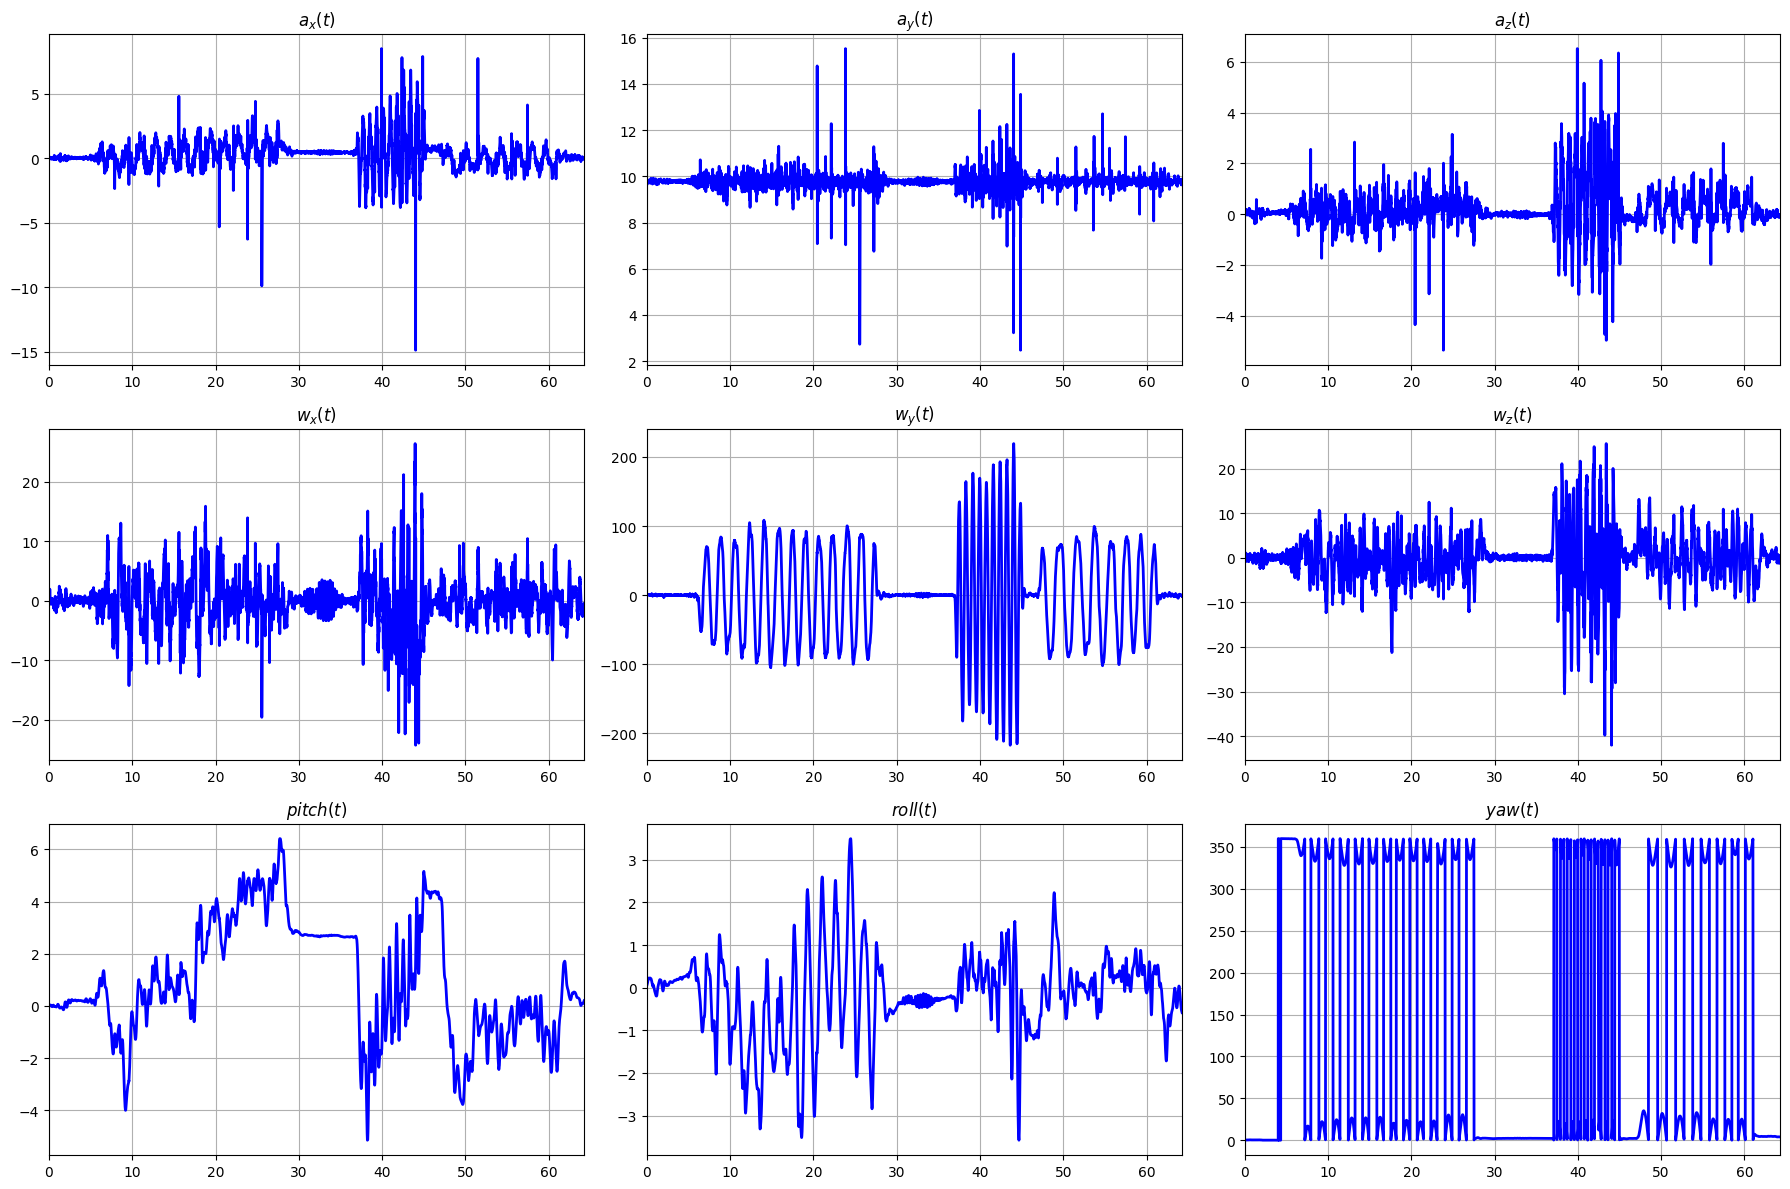

In [10]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals, color='blue', linewidth=2)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

0.01


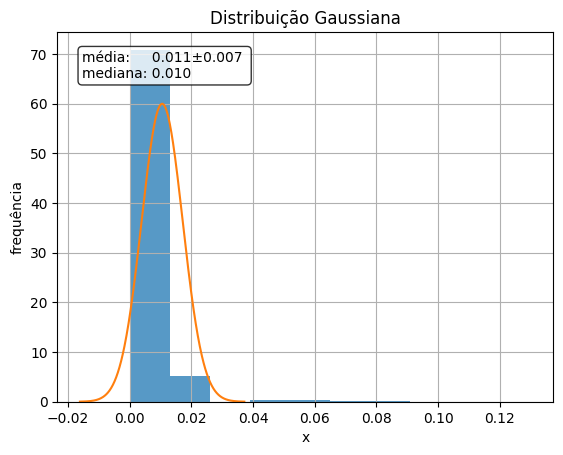

In [11]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
print(dt)
gaussian(time)

In [12]:
def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


df = normalizePeriod(df, 'time', dt)
df

,time,wy,yaw,pitch,ax,ay,q1,wz,q3,roll,q0,az,q2,wx,e
0,0.00,1.05003,0.177,0.070,0.141402,9.814819,0,0.58420,0,0.055,0,-0.065057,0,0.68518,0.0
1,0.01,1.05003,0.177,0.070,0.141402,9.814819,0,0.58420,0,0.055,0,-0.065057,0,0.68518,0.0
2,0.02,0.13414,0.183,0.062,0.117101,9.835305,0,1.12119,0,0.062,0,-0.041816,0,0.34603,0.0
3,0.03,-0.13551,0.185,0.053,0.104147,9.790675,0,1.28399,0,0.069,0,-0.069441,0,0.72055,0.0
4,0.04,-0.42678,0.184,0.044,0.040050,9.769385,0,0.62534,0,0.074,0,-0.010856,0,0.58536,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6424,64.24,-0.83889,3.968,0.173,0.030538,9.802874,0,-0.80409,0,-0.554,0,-0.129222,0,-0.47394,0.0
6425,64.25,-1.29256,3.959,0.181,0.037854,9.860616,0,-0.63506,0,-0.562,0,-0.089241,0,-0.87732,0.0
6426,64.26,-1.10317,3.949,0.188,0.001638,9.865441,0,-0.50122,0,-0.568,0,-0.047994,0,-0.54886,0.0
6427,64.27,-1.04014,3.938,0.195,-0.039609,9.882289,0,-0.69446,0,-0.576,0,-0.045650,0,-0.71032,0.0


# FILTRANDO POR VARIAVEL

In [13]:
df = df.loc[(df.time >= TARGET_TIME[0]) & (df.time <= TARGET_TIME[1])]
df.loc[:, 'time'] = df.time - df.time.values[0]

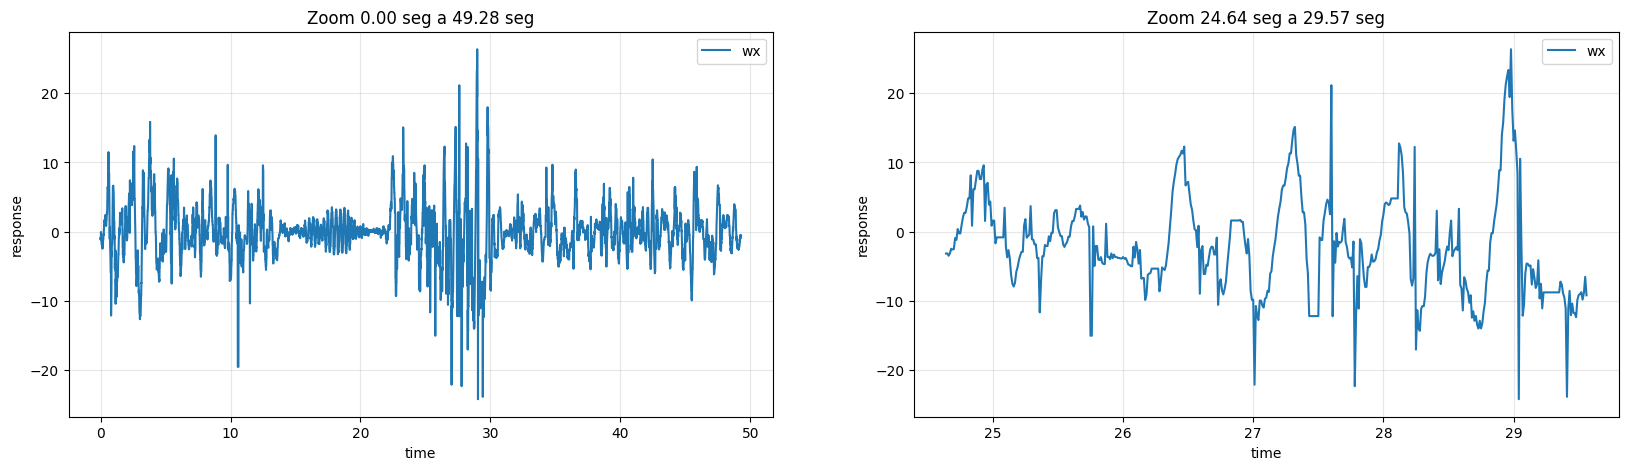

In [14]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df, limits=(0.5, 0.6))

# SALVANDO DADOS

In [15]:
df = df.rename(columns={col: 'target_' + col for col in df.columns if col != 'time'})
df

,time,target_wy,target_yaw,target_pitch,target_ax,target_ay,target_q1,target_wz,target_q3,target_roll,target_q0,target_az,target_q2,target_wx,target_e
1500,0.00,-91.70012,351.928,0.566,-0.204047,9.484855,0,-0.12853,0,-1.547,0,0.805861,0,-1.04879,0.0
1501,0.01,-88.96987,351.027,0.544,-0.017211,9.935411,0,0.67168,0,-1.557,0,0.929719,0,-0.86342,0.0
1502,0.02,-85.33893,349.281,0.496,0.149600,9.807072,0,1.19693,0,-1.572,0,-0.276293,0,-1.15715,0.0
1503,0.03,-83.57597,348.434,0.471,0.693840,10.138713,0,0.28832,0,-1.589,0,0.036834,0,-0.06151,0.0
1504,0.04,-82.54013,347.601,0.446,0.551869,9.821841,0,1.23804,0,-1.608,0,-0.058526,0,-0.63304,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6424,49.24,-0.83889,3.968,0.173,0.030538,9.802874,0,-0.80409,0,-0.554,0,-0.129222,0,-0.47394,0.0
6425,49.25,-1.29256,3.959,0.181,0.037854,9.860616,0,-0.63506,0,-0.562,0,-0.089241,0,-0.87732,0.0
6426,49.26,-1.10317,3.949,0.188,0.001638,9.865441,0,-0.50122,0,-0.568,0,-0.047994,0,-0.54886,0.0
6427,49.27,-1.04014,3.938,0.195,-0.039609,9.882289,0,-0.69446,0,-0.576,0,-0.045650,0,-0.71032,0.0


In [16]:
os.makedirs(f'output', exist_ok=True)
INFO = {}

with open('output/info.json', 'w') as file:
    file.write(json.dumps(INFO, indent=4))

df.to_csv('output/data.csv', index=None)